In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
# Define your color variables
# wt_color = '#c4c4c4' #529e9c'
# tdrd7a_color = '#db97f0'#d16262'
# Create a dictionary mapping conditions to colors
# color_dict = {'wt': wt_color, 'tdrd7a': tdrd7a_color}
color_dict = {
    'wt': '#808080',
    'tdrd7a': '#7B3294',
}
# Define your line style dictionary
line_style_dict = {'wt': '', 'tdrd7a': (2, 2)}  # '' means solid line, (2, 2) means dashed line

In [3]:
df = pd.read_excel('data/all_data.xlsx')

In [4]:
dft = df.copy()

In [5]:
def calc_volume(list_of_areas):
    list_of_volumes = []
    for a in list_of_areas:
        r = np.sqrt(a/np.pi)
        v = (4/3)*np.pi*r**3
        list_of_volumes.append(v)
    return list_of_volumes

In [6]:
# Step 2: Combine the values from these columns into a list for each row, drop the original columns and perform volume calculation
dft['event'] = dft['condition'] + '_' + dft['event-number'].astype(str)
dft['areas'] = dft.filter(regex=("area\d*")).apply(lambda row: row.dropna().tolist(), axis=1)
dft.drop(columns=list(df.filter(regex=("area\d+")).columns.values), inplace=True)
dft['volumes'] = dft['areas'].apply(calc_volume)

In [7]:
# Step 3: Get metrics of from the granule area data
## Area metrics
dft['mean_area'] = dft['areas'].apply(np.mean)
dft['std_area'] = dft['areas'].apply(np.std)
dft['median_area'] = dft['areas'].apply(np.median)
dft['max_area'] = dft['areas'].apply(np.max)
dft['min_area'] = dft['areas'].apply(np.min)
dft['avg area 5 largest'] = dft['areas'].apply(lambda x: np.mean(sorted(x)[-5:]))
dft['sum_area'] = dft['areas'].apply(sum)

## Volume metrics
dft['mean_volume'] = dft['volumes'].apply(np.mean)
dft['std_volume'] = dft['volumes'].apply(np.std)
dft['median_volume'] = dft['volumes'].apply(np.median)
dft['max_volume'] = dft['volumes'].apply(np.max)
dft['min_volume'] = dft['volumes'].apply(np.min)
dft['avg volume 5 largest'] = dft['volumes'].apply(lambda x: np.mean(sorted(x)[-5:]))
dft['granule_count'] = dft['areas'].apply(len)
dft['sum_volume'] = dft['volumes'].apply(sum)
dft['granule_density'] = dft['granule_count'] / dft['sum_area']
# Calculate the 'sum_volume' at time 0 for each 'cell-id' and then calculate the 'relative_sum_volume' for each row
sum_volume_time_0 = dft[dft['time'] == 0].groupby('cell-id')['sum_volume'].first()
dft['relative_sum_volume'] = dft.groupby('cell-id')['sum_volume'].transform(lambda x: x / sum_volume_time_0[x.name])

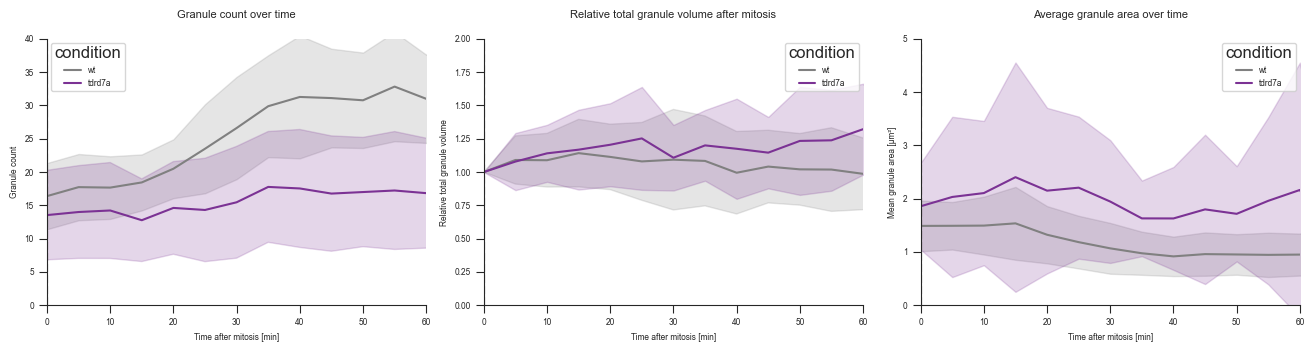

In [8]:
# Step 5: Plotting using seaborn
sns.set_theme(style="ticks")
plt.rcParams.update(
        {
            "font.size": 6,  # default text
            "axes.titlesize": 8,  # subplot titles
            "axes.labelsize": 6,  # x/y axis labels
            "xtick.labelsize": 6,  # x tick labels
            "ytick.labelsize": 6,  # y tick labels
            "legend.fontsize": 6,  # legend
            "figure.titlesize": 8,  # suptitle
        }
    )
# plt.rcParams['font.weight'] = '900'         # For axes labels and titles
# plt.rcParams['axes.labelweight'] = '900'    # For axes labels
# plt.rcParams['axes.titleweight'] = '900'    # For axes titl
axis_style_linewidth = 0.8
plt.rcParams['axes.linewidth'] = axis_style_linewidth  # Thicker axes lines
plt.rcParams['xtick.major.width'] = axis_style_linewidth
plt.rcParams['ytick.major.width'] = axis_style_linewidth
plt.rcParams['font.family'] = 'arial'  # Set the font family to Helvetica

ratio=3.75
y_figsize = 3.5
x_figsize = y_figsize*ratio
# dft_fig = dft.query('condition == "wt"')
dft_fig = dft.query('time < 101').copy()

# Create a figure with 3 subplots
fig, ax = plt.subplots(1, 3, figsize=(x_figsize, y_figsize))

# Settings that will be applied to all subplots
## Set the x-axis limits to -20 and 60
for axs in ax:
    axs.set_xlim(-20, 60)
    axs.axvline(x=0, color='black', linestyle='--')

# Plot of granule count over time
## Plot of granule count over time with error bars
sns.lineplot(data=dft_fig, x='time', y='granule_count', ax=ax[0], hue='condition', errorbar='sd', palette=color_dict)
ax[0].set_title('Granule count over time', pad=15)
ax[0].set_xlim(0, 60)
# ax[0].axvline(x=0, color='white', linestyle='--')
ax[0].set_xlabel('Time after mitosis [min]')
ax[0].set_ylabel('Granule count')
ax[0].set_ylim(0, 40)

## Plot of granule count over time with individual curves
### Plot each curve indexed by 'cell-id'
# sns.lineplot(data=dft, x='time', y='granule_count', hue='condition', style='condition', dashes=line_style_dict, units='cell-id', estimator=None, palette=color_dict, alpha=0.1, ax=ax[0, 0])

# ### Calculate the mean and plot it on top
# mean_df = dft.groupby(['condition', 'time'])['granule_count'].mean().reset_index()
# sns.lineplot(data=mean_df, x='time', y='granule_count', hue='condition', style='condition', dashes=line_style_dict, palette=color_dict, linewidth=2.5, ax=ax[0, 0])
# ax[0, 0].set_title('Granule count over time')
# ax[0, 0].set_xlabel('Time (min)')
# ax[0, 0].set_ylabel('Granule count')

# Plot of total granule volume over time
sns.lineplot(data=dft_fig, x='time', y='relative_sum_volume', ax=ax[1], hue='condition', errorbar='sd', palette=color_dict, markers=True)
ax[1].set_title('Relative total granule volume after mitosis', pad=15)
ax[1].set_xlabel('Time after mitosis [min]')
ax[1].set_ylabel('Relative total granule volume')
ax[1].set_xlim(0, 60)
ax[1].set_ylim(0, 2)

# Plot of granule area over time
sns.lineplot(data=dft_fig, x='time', y='mean_area', ax=ax[2], hue='condition', errorbar='sd', palette=color_dict)
ax[2].set_title('Average granule area over time', pad=15)
ax[2].set_xlabel('Time after mitosis [min]')
ax[2].set_ylabel('Mean granule area [µm²]')
ax[2].set_xlim(0, 60)
ax[2].set_ylim(0, 5)

sns.despine()
plt.tight_layout()
plt.savefig('figures/granules_post-mitosis.pdf', transparent=True)


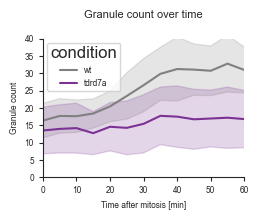

In [9]:
fig_cot, ax_cot = plt.subplots(figsize=(2.6,1.8))
## Plot of granule count over time with error bars
sns.lineplot(data=dft_fig, x='time', y='granule_count', ax=ax_cot, hue='condition', errorbar='sd', palette=color_dict)
ax_cot.set_title('Granule count over time', pad=15)
ax_cot.set_xlim(0, 60)
# ax[0].axvline(x=0, color='white', linestyle='--')
ax_cot.set_xlabel('Time after mitosis [min]')
ax_cot.set_ylabel('Granule count')
ax_cot.set_ylim(0, 40)
ax_cot.tick_params(axis="both", length=3)
sns.despine()
plt.savefig('figures/20260607_granules_count_post_mitosis_for_fig1.pdf', transparent=True)

In [10]:
from scipy.stats import mannwhitneyu

In [11]:
stat_timepoint = 60
wt_end_number_granule = dft.query('condition == "wt" & time == @stat_timepoint')['granule_count'].to_list()
tdrd7a_end_number_granule = dft.query('condition == "tdrd7a" & time == @stat_timepoint')['granule_count'].to_list()
print(mannwhitneyu(wt_end_number_granule, tdrd7a_end_number_granule))


MannwhitneyuResult(statistic=195.5, pvalue=0.00022245387822373387)


In [13]:
print(f"WT number = {len(wt_end_number_granule)}")
print(f"KD number = {len(tdrd7a_end_number_granule)}")

WT number = 18
KD number = 12


In [14]:
dft.query('condition == "tdrd7a" & time == 60')

,condition,stage,date,event-number,cell-id,time,event,areas,volumes,mean_area,...,mean_volume,std_volume,median_volume,max_volume,min_volume,avg volume 5 largest,granule_count,sum_volume,granule_density,relative_sum_volume
417,tdrd7a,10,20230427,1,18,60,tdrd7a_1,"[11.818, 0.499, 0.785, 0.191, 0.286, 2.472, 0....","[30.56185977359072, 0.26516403478218, 0.523200...",1.711231,...,3.093083,7.994346,0.265164,30.561860,0.047694,7.759078,13,40.210079,0.584375,1.344580
433,tdrd7a,10,20230427,2,19,60,tdrd7a_2,"[1.825, 3.936, 0.594, 0.605, 0.159, 0.7, 0.159...","[1.8546335142133399, 5.874168971186746, 0.3443...",0.816923,...,0.811514,1.539381,0.344384,5.874169,0.047694,1.886596,13,10.549686,1.224105,0.725191
469,tdrd7a,12,20230526,4,21,60,tdrd7a_4,"[25.875, 0.955, 1.804]","[99.01120315415267, 0.7020513157808554, 1.8227...",9.544667,...,33.845323,46.081507,1.822714,99.011203,0.702051,33.845323,3,101.535969,0.104771,1.976475
484,tdrd7a,12,20230526,5,22,60,tdrd7a_5,"[0.149, 0.286, 19.457, 0.17, 1.22, 0.35, 0.87,...","[0.04326564702839186, 0.11505694805449071, 64....",2.574444,...,7.427198,20.202532,0.155764,64.562096,0.043266,13.302395,9,66.844784,0.388433,1.136643
501,tdrd7a,12,20230526,6,23,60,tdrd7a_6,"[0.212, 4.403, 0.52, 1.018, 4.021, 0.403, 0.88...","[0.07342899626138726, 6.95003238784556, 0.2820...",1.744429,...,3.793361,13.848660,0.177808,75.014061,0.043266,19.530885,28,106.214121,0.573254,1.143889
518,tdrd7a,12,20230526,7,24,60,tdrd7a_7,"[0.509, 3.925, 0.159, 0.658, 0.244, 0.477, 0.2...","[0.2731746993451229, 5.849561237993858, 0.0476...",1.087935,...,1.325853,2.907201,0.247823,15.454058,0.047694,6.177258,31,41.101431,0.919172,1.278513
533,tdrd7a,12,20230802,8,25,60,tdrd7a_8,"[0.934, 4.795, 0.297, 0.244, 1.114, 0.509, 0.2...","[0.6790224208283376, 7.898538102480928, 0.1217...",0.785857,...,0.740241,1.503626,0.269169,7.898538,0.047694,2.962396,28,20.726750,1.272496,1.243149
547,tdrd7a,12,20230802,9,26,60,tdrd7a_9,"[0.414, 0.615, 1.029, 0.615, 0.647, 1.687, 0.7...","[0.20038458613809276, 0.36280768182886947, 0.7...",1.247812,...,1.455510,2.582215,0.462863,10.602910,0.047694,3.870765,16,23.288165,0.801402,1.299359
560,tdrd7a,12,20230802,10,27,60,tdrd7a_10,"[2.758, 0.753, 0.159, 0.202, 1.867, 1.029, 0.5...","[3.4455233149801647, 0.49153705663792446, 0.04...",1.393625,...,1.995673,4.576345,0.382356,19.267195,0.047694,5.829492,16,31.930769,0.717553,1.655296
574,tdrd7a,12,20230802,11,28,60,tdrd7a_11,"[0.18, 0.286, 0.223, 0.265, 1.061, 0.53, 3.395...","[0.0574476883778063, 0.11505694805449071, 0.07...",1.050824,...,1.143288,1.734092,0.207689,5.614205,0.057448,3.434299,17,19.435891,0.951635,1.779903
